In [3]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Random walk in two dimensions

In [4]:
def random_walk(number_of_steps):
    x = 0
    for step in range(number_of_steps):
        if np.random.rand()<0.5:
            x = x+1
        else:
            x = x-1

    return x

In [6]:
trial = 10
Nsteps = 10
p = []
for t in range(trial):
    xfinal = random_walk(Nsteps)
    p.append(xfinal)
print(p)    

[6, 4, 2, 0, 0, -2, 0, 2, 0, -2]


[0, 0] [-5, -19]
[0, 0] [-10, -14]


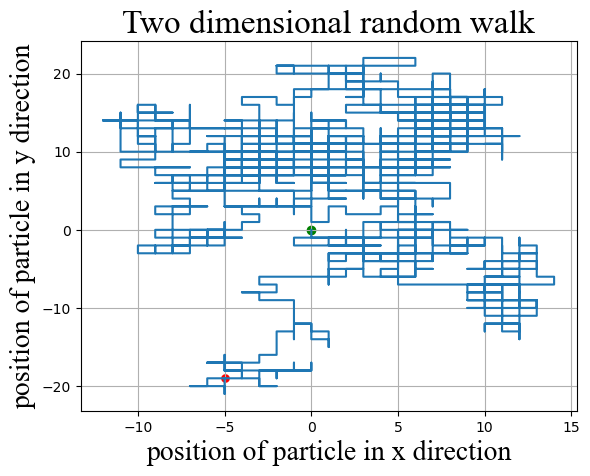

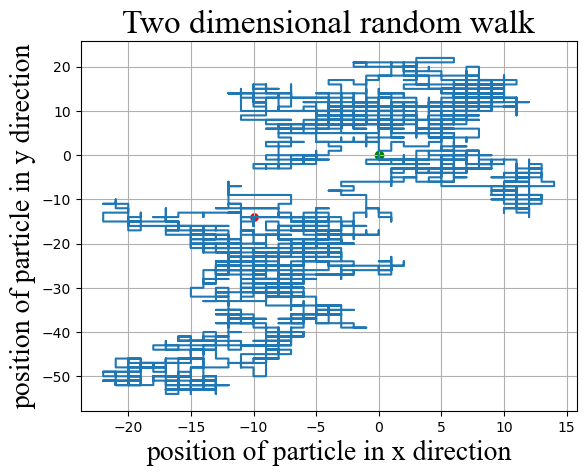

In [11]:
trial = 2
number_of_steps = 2000
x = 0
y = 0
posx = [0]
posy = [0]
for j in range(trial):
    for i in range(number_of_steps):
        switch = np.random.randint(4)
        if switch == 0:
            x,y = x+1,y
            
        elif switch == 1:
            x,y = x-1,y
            
        elif switch == 2:
            y,x = y+1,x
            
        elif switch == 3:
            y,x = y-1,x
        posx.append(x)    
        posy.append(y)                
    print([posx[0],posy[0]],[posx[-1], posy[-1]])
    plt.figure()
    plt.scatter(posx[0], posy[0], color = 'green')
    plt.scatter(posx[-1], posy[-1], color = 'red', linewidths=0.2)
    plt.plot(posx, posy)
    
    plt.xlabel('position of particle in x direction', font = 'times new roman', size = 20)
    plt.ylabel('position of particle in y direction', font = 'times new roman', size = 20)
    plt.title('Two dimensional random walk', font = 'times new roman', size = 24)
    plt.grid()

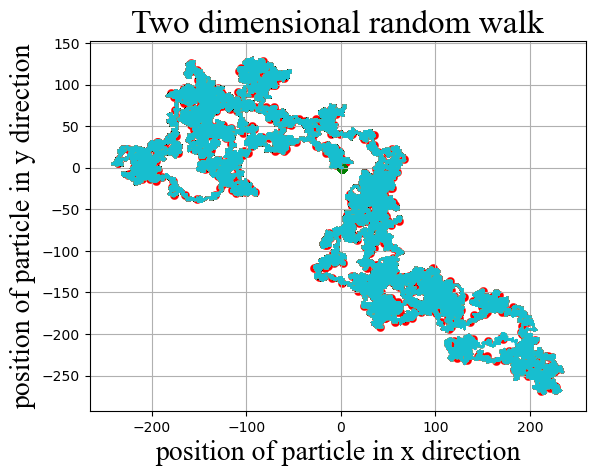

In [17]:
number_of_particles = 1000
number_of_steps = 100
x = 0
y = 0
posx = []
posy = []
plt.figure()
for i in range(number_of_particles):
    for i in range(number_of_steps):
        switch = np.random.randint(4)
        if switch == 0:
            x = x+1
            y = y
            
        elif switch == 1:
            x = x-1
            y = y
            
        elif switch == 2:
            y = y+1
            x = x
            
        elif switch == 3:
            y = y-1
            x = x
        posx.append(x)    
        posy.append(y)
    #print([posx[0],posy[0]],[posx[-1], posy[-1]])
    plt.scatter(posx[0], posy[0], color = 'green')
    plt.scatter(posx[-1], posy[-1], color = 'red', linewidths=0.2)
    plt.plot(posx, posy)
    
plt.xlabel('position of particle in x direction', font = 'times new roman', size = 20)
plt.ylabel('position of particle in y direction', font = 'times new roman', size = 20)
plt.title('Two dimensional random walk', font = 'times new roman', size = 24)
plt.grid()        

In [12]:
N = 1000
sigma = 1
x = np.zeros(N)
y = np.zeros(N)
for i in range(N):
    d = np.random.normal(0, sigma)
    theta = 180*np.random.random()/np.pi
    x[i] = x[i-1] + d*np.cos(theta)
    y[i] = y[i-1] + d*np.sin(theta)

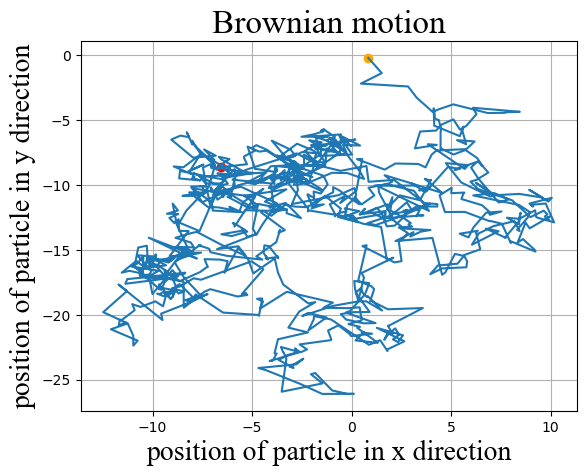

In [13]:
plt.plot(x,y)
plt.scatter(x[0], y[0], color = 'orange')
plt.scatter(x[-1], y[-1], color = 'red')
plt.xlabel('position of particle in x direction', font = 'times new roman', size = 20)
plt.ylabel('position of particle in y direction', font = 'times new roman', size = 20)
plt.title('Brownian motion', font = 'times new roman', size = 24)
plt.grid()

### 2. Random collision and Maxwell-Boltzmann distribution

In [18]:
# 1.non-equilibrium initial state
N = 1000000
trials = 1
sigma = 2
 
for trial in range(trials):
    vx,vy = np.zeros(N),np.zeros(N)
    vcmx,vcmy = np.zeros(N),np.zeros(N)
    ux,uy = np.zeros(N),np.zeros(N)
    vx1,vy1 = np.zeros(N),np.zeros(N)
    vx2,vy2 = np.zeros(N),np.zeros(N)
    v1,v2 = np.zeros(N),np.zeros(N)
    
    for i in range(N):
        vx[i] += np.random.normal(0, sigma)
        vy[i] += np.random.normal(0, sigma)
    #print(vx)
    #print(vy)
    
    # 2.calculating the meam of velocity   
    for j in range(N//2):
        vcmx[2*j] += 0.5*(vx[2*j]+vx[2*j+1])
        vcmy[2*j] += 0.5*(vy[2*j]+vy[2*j+1])
    # need to fill all the vacant space
    for j in range(N//2):
        vcmx[2*j+1] = vcmx[2*j]  
        vcmy[2*j+1] = vcmy[2*j]    
       
    #print(vcmx)
    #print(vcmy)
    
    # 3.magnitude of relative valocity
    for k in range(N):
        ux[k] += (vx[k]-vcmx[k])
        uy[k] += (vy[k]-vcmy[k])
        
    #print(ux)
    #print(uy)
    #plt.plot(np.sqrt(ux**2+uy**2))
    
    for i in range(N):
        theta = 180*np.random.random()/np.pi
        vx1[i] += vcmx[i] + ux[i]*np.cos(theta)
        vy1[i] += vcmy[i] + uy[i]*np.sin(theta)
        vx2[i] += vcmx[i] - ux[i]*np.cos(theta)
        vy2[i] += vcmy[i] - uy[i]*np.sin(theta)
        v1[i] += np.sqrt(vx1[i]**2+vy1[i]**2)
        v2[i] += np.sqrt(vx2[i]**2+vy2[i]**2)
#plt.hist(v1, bins = 1000)    
#plt.hist(v2, bins = 1000)


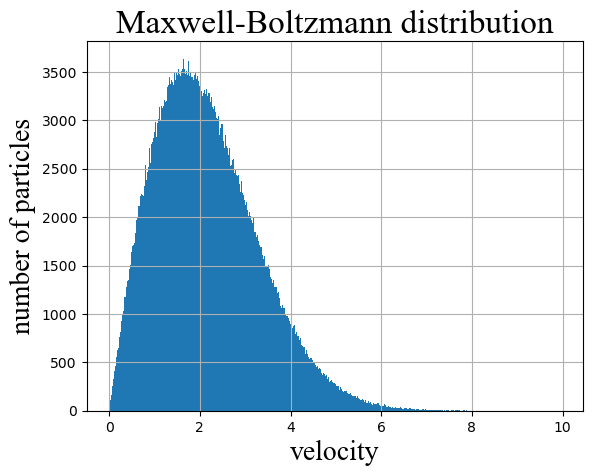

In [19]:
plt.hist(v1, bins = 1000)
plt.xlabel('velocity', font = 'times new roman', size = 20)
plt.ylabel('number of particles', font = 'times new roman', size = 20)
plt.title('Maxwell-Boltzmann distribution', font = 'times new roman', size = 24)
plt.grid()

In [22]:
heights = np.random.randint(1, 9, 10)
h = np.ones_like(heights)
q = np.zeros_like(heights)
print(heights)
print(h)
print(q)

[4 1 5 3 3 3 7 2 1 7]
[1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 0 0 0 0 0]


In [23]:
min(heights), max(heights)

(np.int64(1), np.int64(7))

In [24]:
min_val, max_val = 130, 190